# Quantile Regression & CQR — hoàn thiện Uncertainty Quantification

Tiếp nối `01_conformal_prediction.ipynb`. Bổ sung 2 phương pháp còn thiếu và so sánh cả 3.

---

## Ba phương pháp

| # | Tên | Cách hoạt động | Bảo đảm phủ 90%? | Khoảng co giãn theo |
|---|---|---|---|---|
| **A** | **Conformal chuẩn hoá** | Đo sai số quá khứ → suy khoảng theo % | ✅ **Có** | Mức giá |
| **B** | **Quantile Regression** | Train model dự đoán thẳng P05/P95 | ❌ Không | **Mọi feature** |
| **C** | **CQR** ⭐ | QR + hiệu chỉnh bằng conformal | ✅ **Có** | **Mọi feature** |

**CQR (Conformalized Quantile Regression)** kết hợp ưu điểm cả hai: khoảng thích ứng theo từng
chuyến **và** vẫn giữ cam kết toán học về tỷ lệ phủ.

## Vì sao QR có thể tốt hơn

Conformal chuẩn hoá chỉ co giãn theo **mức giá** — chuyến 200k luôn có khoảng rộng gấp đôi chuyến
100k. Nhưng thực tế có chuyến **dễ đoán** (tuyến quen, giờ ổn định) và chuyến **khó đoán** (giờ cao
điểm, thời tiết xấu) — QR bắt được sự khác biệt đó.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90
print(f"Muc tin cay muc tieu: {MUC*100:.0f}%")

Muc tin cay muc tieu: 90%


## 1. Nạp dữ liệu — dự đoán điểm (Hybrid) và dự đoán phân vị (QR)

In [2]:
# --- Du doan diem tu Hybrid (cho phuong phap A) ---
cal_h = pd.read_parquet("../evaluation/uq_pred_calibration.parquet")
tes_h = pd.read_parquet("../evaluation/uq_pred_test.parquet")

# --- Du doan phan vi tu Quantile Regression (cho B va C) ---
cal_q = pd.read_parquet("../evaluation/qr_pred_calibration.parquet")
tes_q = pd.read_parquet("../evaluation/qr_pred_test.parquet")

assert len(cal_h) == len(cal_q) and len(tes_h) == len(tes_q)
assert np.allclose(cal_h.gia_that.values, cal_q.gia_that.values), "Lech calibration"
assert np.allclose(tes_h.gia_that.values, tes_q.gia_that.values), "Lech test"
print("Can hang: OK")

cal = cal_q.copy(); cal["hybrid_pred"] = cal_h.hybrid_pred.values
tes = tes_q.copy(); tes["hybrid_pred"] = tes_h.hybrid_pred.values

print(f"\nCALIBRATION: {len(cal):,} dong")
print(f"TEST       : {len(tes):,} dong")
print(f"\nMAE cua P50 (QR)     : {np.abs(tes.q50 - tes.gia_that).mean():,.0f}d")
print(f"MAE cua Hybrid       : {np.abs(tes.hybrid_pred - tes.gia_that).mean():,.0f}d")

Can hang: OK

CALIBRATION: 615,908 dong
TEST       : 864,360 dong

MAE cua P50 (QR)     : 18,829d
MAE cua Hybrid       : 18,048d


## 2. Phương pháp A — Conformal chuẩn hoá (nhắc lại từ notebook 01)

In [3]:
sai_so_rel = np.abs(cal.hybrid_pred - cal.gia_that) / cal.hybrid_pred
q_rel = np.quantile(sai_so_rel, MUC)

tes["A_low"]  = tes.hybrid_pred * (1 - q_rel)
tes["A_high"] = tes.hybrid_pred * (1 + q_rel)

print(f"PP A — Conformal chuan hoa")
print(f"  Nguong: +/-{q_rel*100:.2f}%")

PP A — Conformal chuan hoa
  Nguong: +/-30.09%


## 3. Phương pháp B — Quantile Regression thô

Dùng thẳng `[P05, P95]` do model dự đoán, **không hiệu chỉnh**.

In [4]:
tes["B_low"]  = tes.q05
tes["B_high"] = tes.q95

phu_cal = ((cal.gia_that >= cal.q05) & (cal.gia_that <= cal.q95)).mean()
phu_tes = ((tes.gia_that >= tes.q05) & (tes.gia_that <= tes.q95)).mean()
print(f"PP B — Quantile Regression tho")
print(f"  Coverage tren CALIBRATION : {phu_cal*100:.2f}%")
print(f"  Coverage tren TEST        : {phu_tes*100:.2f}%   (muc tieu {MUC*100:.0f}%)")
print(f"  -> Lech {abs(phu_tes-MUC)*100:.2f} diem % — QR KHONG bao dam ty le phu")

PP B — Quantile Regression tho
  Coverage tren CALIBRATION : 89.53%
  Coverage tren TEST        : 89.09%   (muc tieu 90%)
  -> Lech 0.91 diem % — QR KHONG bao dam ty le phu


## 4. ⭐ Phương pháp C — CQR (Conformalized Quantile Regression)

**Ý tưởng:** lấy khoảng của QR, rồi **nới ra hoặc thu vào** một lượng đúng bằng mức cần thiết để
đạt 90%, đo trên tập calibration.

**Điểm số bất tuân (conformity score):**

$$E_i = \max\big(\underbrace{q_{05}^{(i)} - y_i}_{\text{hụt dưới}},\ \underbrace{y_i - q_{95}^{(i)}}_{\text{vượt trên}}\big)$$

- $E_i < 0$ → giá thật **nằm trong** khoảng (còn dư chỗ)
- $E_i > 0$ → giá thật **nằm ngoài**, lệch ra bấy nhiêu

Lấy phân vị 90% của $E$ rồi cộng vào 2 đầu khoảng.

In [5]:
# --- Diem bat tuan tren CALIBRATION ---
E = np.maximum(cal.q05 - cal.gia_that, cal.gia_that - cal.q95)
n = len(cal)
# hieu chinh huu han mau: dung phan vi ceil((n+1)*muc)/n
k = int(np.ceil((n + 1) * MUC))
k = min(k, n)
q_cqr = np.sort(E.values)[k - 1]

tes["C_low"]  = tes.q05 - q_cqr
tes["C_high"] = tes.q95 + q_cqr

print(f"PP C — CQR")
print(f"  Diem bat tuan E: min {E.min():,.0f} | median {E.median():,.0f} | max {E.max():,.0f}")
print(f"  Nguong hieu chinh q = {q_cqr:,.0f}d")
if q_cqr > 0:
    print(f"  -> NOI RONG khoang QR them {q_cqr:,.0f}d moi ben")
else:
    print(f"  -> THU HEP khoang QR di {abs(q_cqr):,.0f}d moi ben")

PP C — CQR
  Diem bat tuan E: min -154,159 | median -18,660 | max 379,314
  Nguong hieu chinh q = 333d
  -> NOI RONG khoang QR them 333d moi ben


## 5. So sánh 3 phương pháp trên TEST

In [6]:
def danh_gia(lo, hi, ten):
    phu = ((tes.gia_that >= lo) & (tes.gia_that <= hi)).mean()
    rong = (hi - lo)
    return {"Phuong phap": ten,
            "Coverage (%)": phu * 100,
            "Do rong TB (d)": rong.mean(),
            "Do rong trung vi (d)": rong.median(),
            "Do rong / gia (%)": (rong / tes.gia_that).mean() * 100}

kq = pd.DataFrame([
    danh_gia(tes.A_low, tes.A_high, "A. Conformal chuan hoa"),
    danh_gia(tes.B_low, tes.B_high, "B. Quantile Regression"),
    danh_gia(tes.C_low, tes.C_high, "C. CQR"),
])
kq["Lech vs 90%"] = (kq["Coverage (%)"] - MUC*100).round(2)
display(kq.round(1))

dat = kq[np.abs(kq["Lech vs 90%"]) < 1.0]
if len(dat):
    tot = dat.loc[dat["Do rong TB (d)"].idxmin()]
    print(f">>> Dat coverage VA hep nhat: {tot['Phuong phap']} "
          f"({tot['Coverage (%)']:.2f}%, rong {tot['Do rong TB (d)']:,.0f}d)")

,Phuong phap,Coverage (%),Do rong TB (d),Do rong trung vi (d),Do rong / gia (%),Lech vs 90%
0,A. Conformal chuan hoa,89.6,72629.8,69408.5,61.1,-0.4
1,B. Quantile Regression,89.1,75782.9,73465.4,63.4,-0.9
2,C. CQR,89.5,76448.9,74131.4,64.0,-0.5


>>> Dat coverage VA hep nhat: A. Conformal chuan hoa (89.55%, rong 72,630d)


## 6. Conditional coverage — kiểm tra theo từng nhóm

In [7]:
tes["dai_km"] = pd.cut(tes.quang_duong, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])
tes["mua"] = tes.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

def khung(h):
    if h < 5:  return "0. Dem khuya"
    if h < 7:  return "1. Sang som"
    if h < 9:  return "2. Cao diem sang"
    if h < 16: return "3. Giua ngay"
    if h < 19: return "4. Cao diem chieu"
    return "5. Toi"
tes["khung"] = tes.gio_vn.apply(khung)


def cov_theo(cot, ten):
    rows = []
    for nhom, s in tes.groupby(cot, observed=True):
        r = {"Nhom": str(nhom), "n": len(s)}
        for k_ in ["A", "B", "C"]:
            r[k_] = ((s.gia_that >= s[f"{k_}_low"]) & (s.gia_that <= s[f"{k_}_high"])).mean() * 100
        rows.append(r)
    df = pd.DataFrame(rows)
    print(f"\nCOVERAGE THEO {ten.upper()}  (muc tieu {MUC*100:.0f}%)")
    display(df.round(2))
    return df

c_dai = cov_theo("dai_km", "dai quang duong")
c_gio = cov_theo("khung", "khung gio")
c_lag = cov_theo("requested_lag_minutes", "do tre quan sat")

print("\n" + "=" * 60)
print("DO LECH LON NHAT so voi 90% (cang nho cang tot)")
print("=" * 60)
for ten, df in [("Dai quang duong", c_dai), ("Khung gio", c_gio), ("Do tre lag", c_lag)]:
    print(f"  {ten:18s}", end="")
    for k_ in ["A", "B", "C"]:
        print(f"  {k_}: {np.abs(df[k_] - MUC*100).max():5.2f}", end="")
    print()


COVERAGE THEO DAI QUANG DUONG  (muc tieu 90%)


,Nhom,n,A,B,C
0,<3km,57968,94.17,87.45,89.42
1,3-5km,82664,89.61,89.02,89.52
2,5-7km,397492,89.24,89.37,89.75
3,7-10km,286408,89.16,89.15,89.41
4,>10km,39828,88.67,88.39,88.71



COVERAGE THEO KHUNG GIO  (muc tieu 90%)


,Nhom,n,A,B,C
0,0. Dem khuya,137584,89.88,88.89,89.76
1,1. Sang som,76892,89.72,89.31,89.81
2,2. Cao diem sang,77112,89.85,89.50,89.86
3,3. Giua ngay,266720,89.64,89.35,89.71
4,4. Cao diem chieu,114488,89.11,88.49,88.84
5,5. Toi,191564,89.29,88.98,89.34



COVERAGE THEO DO TRE QUAN SAT  (muc tieu 90%)

,Nhom,n,A,B,C
0,5,216090,89.82,89.22,89.67
1,10,216090,89.70,89.12,89.58
2,15,216090,89.56,89.03,89.48
3,30,216090,89.14,89.00,89.44



DO LECH LON NHAT so voi 90% (cang nho cang tot)
  Dai quang duong     A:  4.17  B:  2.55  C:  1.29
  Khung gio           A:  0.89  B:  1.51  C:  1.16
  Do tre lag          A:  0.86  B:  1.00  C:  0.56


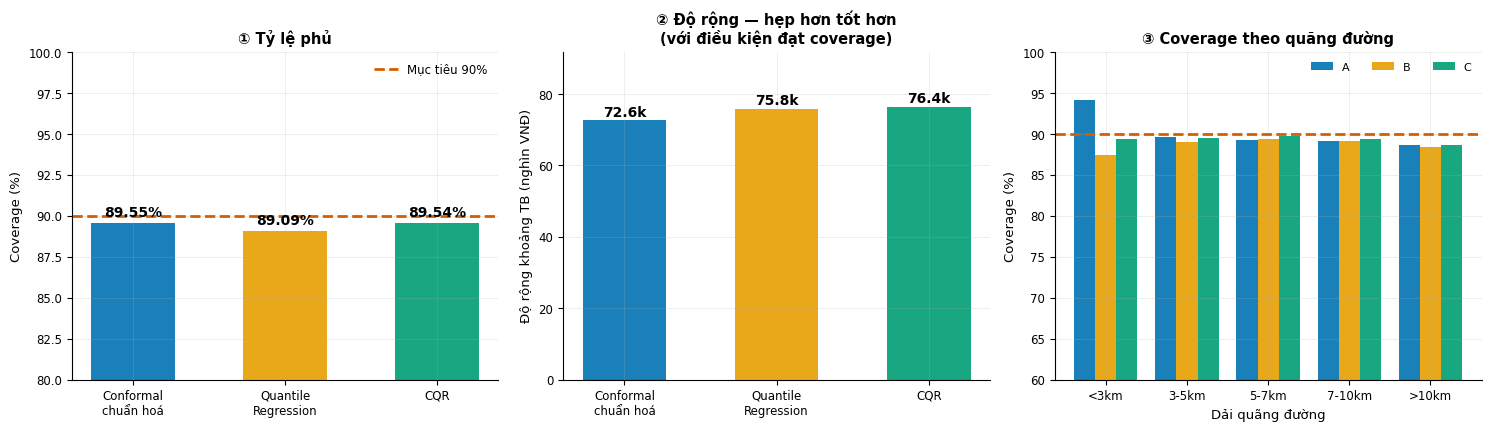

In [8]:
# ═════════ HINH UQ3 — so sanh 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
TEN = ["Conformal\nchuẩn hoá", "Quantile\nRegression", "CQR"]
MAU = [BLUE, ORANGE, GREEN]

cov = kq["Coverage (%)"].values
b_ = ax[0].bar(range(3), cov, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b_, cov):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+0.4, f"{v:.2f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label="Mục tiêu 90%")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(TEN, fontsize=8.5)
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(80, 100)
ax[0].set_title("① Tỷ lệ phủ", fontweight="bold"); ax[0].legend(frameon=False)

rong = kq["Do rong TB (d)"].values / 1000
b2 = ax[1].bar(range(3), rong, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b2, rong):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.1f}k", ha="center",
               fontsize=10, fontweight="bold")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(TEN, fontsize=8.5)
ax[1].set_ylabel("Độ rộng khoảng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng — hẹp hơn tốt hơn\n(với điều kiện đạt coverage)", fontweight="bold")
ax[1].set_ylim(0, max(rong)*1.2)

x = np.arange(len(c_dai)); w = 0.26
for i, (col, k_) in enumerate(zip(MAU, ["A", "B", "C"])):
    ax[2].bar(x + (i-1)*w, c_dai[k_], w, color=col, alpha=0.9, label=k_)
ax[2].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[2].set_xticks(x); ax[2].set_xticklabels(c_dai.Nhom, fontsize=8.5)
ax[2].set_xlabel("Dải quãng đường"); ax[2].set_ylabel("Coverage (%)")
ax[2].set_title("③ Coverage theo quãng đường", fontweight="bold")
ax[2].set_ylim(60, 100); ax[2].legend(frameon=False, ncol=3, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "UQ3_so_sanh_3pp.png"); plt.show()

## 7. ⭐ Khoảng có **thích ứng** theo độ khó không?

Đây là ưu điểm chính QR/CQR hứa hẹn: khoảng **hẹp ở chuyến dễ**, **rộng ở chuyến khó**.

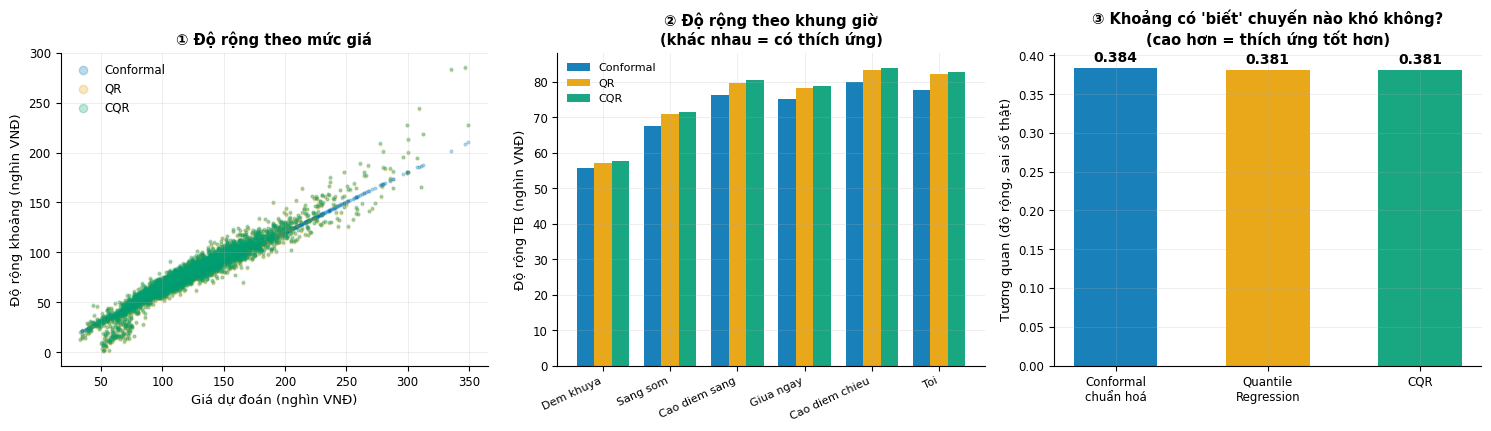

,PP,corr
0,Conformal,0.3841
1,QR,0.3809
2,CQR,0.3809


In [9]:
tes["A_rong"] = tes.A_high - tes.A_low
tes["B_rong"] = tes.B_high - tes.B_low
tes["C_rong"] = tes.C_high - tes.C_low
tes["sai_so"] = np.abs(tes.hybrid_pred - tes.gia_that)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) Do rong vs gia du doan
s = tes.sample(5000, random_state=1)
for k_, col, ten in zip(["A", "B", "C"], MAU, ["Conformal", "QR", "CQR"]):
    ax[0].scatter(s.hybrid_pred/1000, s[f"{k_}_rong"]/1000, s=4, alpha=0.25, color=col, label=ten)
ax[0].set_xlabel("Giá dự đoán (nghìn VNĐ)"); ax[0].set_ylabel("Độ rộng khoảng (nghìn VNĐ)")
ax[0].set_title("① Độ rộng theo mức giá", fontweight="bold")
ax[0].legend(frameon=False, markerscale=3)

# (b) Do rong theo khung gio
gg = tes.groupby("khung")
xk = np.arange(len(gg))
for i, (k_, col) in enumerate(zip(["A", "B", "C"], MAU)):
    ax[1].bar(xk + (i-1)*0.26, gg[f"{k_}_rong"].mean()/1000, 0.26, color=col, alpha=0.9,
              label=["Conformal", "QR", "CQR"][i])
ax[1].set_xticks(xk)
ax[1].set_xticklabels([k.split(". ")[1] for k in gg.groups.keys()], rotation=25, ha="right", fontsize=8)
ax[1].set_ylabel("Độ rộng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng theo khung giờ\n(khác nhau = có thích ứng)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# (c) Tuong quan do rong vs sai so thuc te
rows = []
for k_ in ["A", "B", "C"]:
    rows.append({"PP": ["Conformal", "QR", "CQR"][["A","B","C"].index(k_)],
                 "corr": np.corrcoef(tes[f"{k_}_rong"], tes.sai_so)[0, 1]})
cr = pd.DataFrame(rows)
b3 = ax[2].bar(range(3), cr["corr"], color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b3, cr["corr"]):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+0.008, f"{v:.3f}", ha="center",
               fontsize=10, fontweight="bold")
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(TEN, fontsize=8.5)
ax[2].set_ylabel("Tương quan (độ rộng, sai số thật)")
ax[2].set_title("③ Khoảng có 'biết' chuyến nào khó không?\n(cao hơn = thích ứng tốt hơn)",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH / "UQ4_thich_ung.png"); plt.show()
display(cr.round(4))

## 8. Kết luận

In [10]:
print("=" * 68)
print("TONG KET UNCERTAINTY QUANTIFICATION")
print("=" * 68)
for _, r in kq.iterrows():
    print(f"  {r['Phuong phap']:26s} coverage {r['Coverage (%)']:6.2f}%  "
          f"| rong {r['Do rong TB (d)']:>9,.0f}d")
print()
print("Do lech lon nhat theo nhom:")
for ten, df in [("Dai quang duong", c_dai), ("Khung gio", c_gio), ("Do tre", c_lag)]:
    print(f"  {ten:18s}", end="")
    for k_ in ["A", "B", "C"]:
        print(f"  {k_}: {np.abs(df[k_] - MUC*100).max():5.2f}", end="")
    print()
print()
print("Thich ung theo do kho (tuong quan do rong vs sai so):")
for _, r in cr.iterrows():
    print(f"  {r['PP']:12s} {r['corr']:.4f}")

TONG KET UNCERTAINTY QUANTIFICATION
  A. Conformal chuan hoa     coverage  89.55%  | rong    72,630d
  B. Quantile Regression     coverage  89.09%  | rong    75,783d
  C. CQR                     coverage  89.54%  | rong    76,449d

Do lech lon nhat theo nhom:
  Dai quang duong     A:  4.17  B:  2.55  C:  1.29
  Khung gio           A:  0.89  B:  1.51  C:  1.16
  Do tre              A:  0.86  B:  1.00  C:  0.56

Thich ung theo do kho (tuong quan do rong vs sai so):
  Conformal    0.3841
  QR           0.3809
  CQR          0.3809


### Ba tiêu chí đánh giá

| Tiêu chí | Ý nghĩa |
|---|---|
| **Coverage** | Có đạt đúng 90% không |
| **Độ rộng** | Hẹp hơn = hữu ích hơn (với điều kiện đạt coverage) |
| **Thích ứng** | Khoảng có rộng ra đúng ở chuyến khó không |

### ⚠️ Giới hạn chung của cả 3 phương pháp

| Điểm | Chi tiết |
|---|---|
| **Không cải thiện dự đoán** | UQ chỉ **đo** độ bất định, không làm model chính xác hơn |
| **Giả định trao đổi được** | Calibration và test phải cùng phân phối — ở đây tách theo thời gian trong cùng tháng |
| **Khoảng vẫn rộng** | Phản ánh đúng sàn nhiễu MAE ~18k, không phải lỗi phương pháp |

### Bước tiếp theo

Nối khoảng dự đoán vào **acceptance model**: khi khoảng rộng (không chắc giá đối thủ) thì nên định
giá **thận trọng** hơn — đây là mắt xích cuối nối cả 3 cấu phần đề bài.